# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import shap
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error
from optuna.importance import get_param_importances
from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED,
    AIR_GENRE_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import (
    plot_daily_pred,
    plot_daily_error_overall,
    plot_daily_error_by_group
)
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
    get_daily_error_stats_table,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-02-15 12:28:28.204 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 40
SECOND_ITER_TRIALS = 200
FS_VALID_SIZE = 0.2
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    AIR_GENRE_COL,
    *USELESS_FEATURES,
]

MODEL_NAME = "lgbm_optuna_recursive"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

# mlflow.set_experiment(f"recruit_restaurant_visitors_v04")

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [ ]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    window_test_size=39,
    mlflow_run_name="study_first_iter"
)
print_best_params(study)

In [12]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
39,"{'model__max_depth': 4, 'model__learning_rate'...",0.139629,0.972656,1.016393,0.891298,0.874781,0.853067,1.227742,1
27,"{'model__max_depth': 4, 'model__learning_rate'...",0.142375,0.972761,1.016319,0.892157,0.872021,0.850189,1.233120,2
17,"{'model__max_depth': 4, 'model__learning_rate'...",0.141749,0.974103,1.019284,0.893747,0.873966,0.850994,1.232525,3
21,"{'model__max_depth': 5, 'model__learning_rate'...",0.141256,0.974748,1.027798,0.892532,0.874614,0.849917,1.228880,4
14,"{'model__max_depth': 4, 'model__learning_rate'...",0.143250,0.974861,1.019317,0.894710,0.873781,0.850076,1.236422,5


### SHAP feature selection

In [15]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [ ]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=8,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
    window_test_size=39,
    mlflow_run_name="study_second_iter"
)
print_best_params(study)

In [18]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
165,"{'model__max_depth': 3, 'model__learning_rate'...",0.135442,0.951018,0.962492,0.861122,0.865414,0.855930,1.210133,1
174,"{'model__max_depth': 3, 'model__learning_rate'...",0.134718,0.951612,0.969544,0.862111,0.868016,0.851168,1.207220,2
154,"{'model__max_depth': 3, 'model__learning_rate'...",0.133552,0.952275,0.983118,0.859627,0.867117,0.850264,1.201247,3
160,"{'model__max_depth': 3, 'model__learning_rate'...",0.135104,0.952982,0.976638,0.858226,0.868856,0.853673,1.207515,4
168,"{'model__max_depth': 3, 'model__learning_rate'...",0.134569,0.953331,0.974361,0.860045,0.870119,0.854442,1.207686,5


### Scores

In [19]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")

Train set metrics:
RMSLE: 0.8747
MAE:  6.9665


In [6]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 90/90 [01:09<00:00,  1.30it/s]


In [7]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")


Test set metrics:
RMSLE: 0.8279
MAE:  7.0716


## Graphs

### Optuna importances

In [15]:
get_param_importances(study)

{'n_estimators': np.float64(0.49786421025438676),
 'learning_rate': np.float64(0.37638684884550955),
 'colsample_bytree': np.float64(0.042442236140901715),
 'keep_count': np.float64(0.04044001552943371),
 'subsample': np.float64(0.014216292812751902),
 'min_child_samples': np.float64(0.013210692656049601),
 'num_leaves': np.float64(0.012187938307868332),
 'reg_lambda': np.float64(0.002352459030549681),
 'reg_alpha': np.float64(0.000899306422548707)}

### SHAP explanation

In [53]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

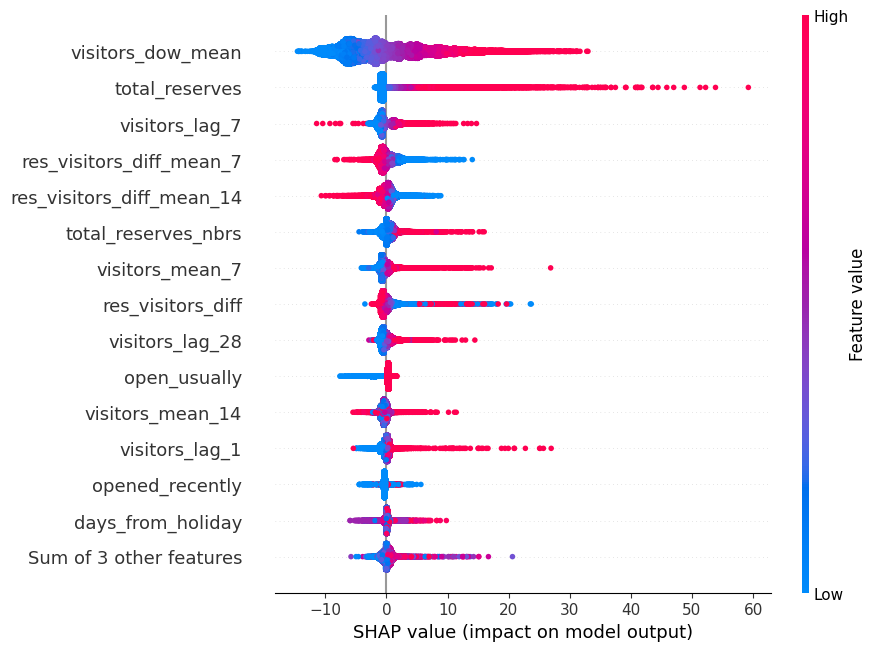

In [54]:
shap.plots.beeswarm(shap_values, max_display=15)

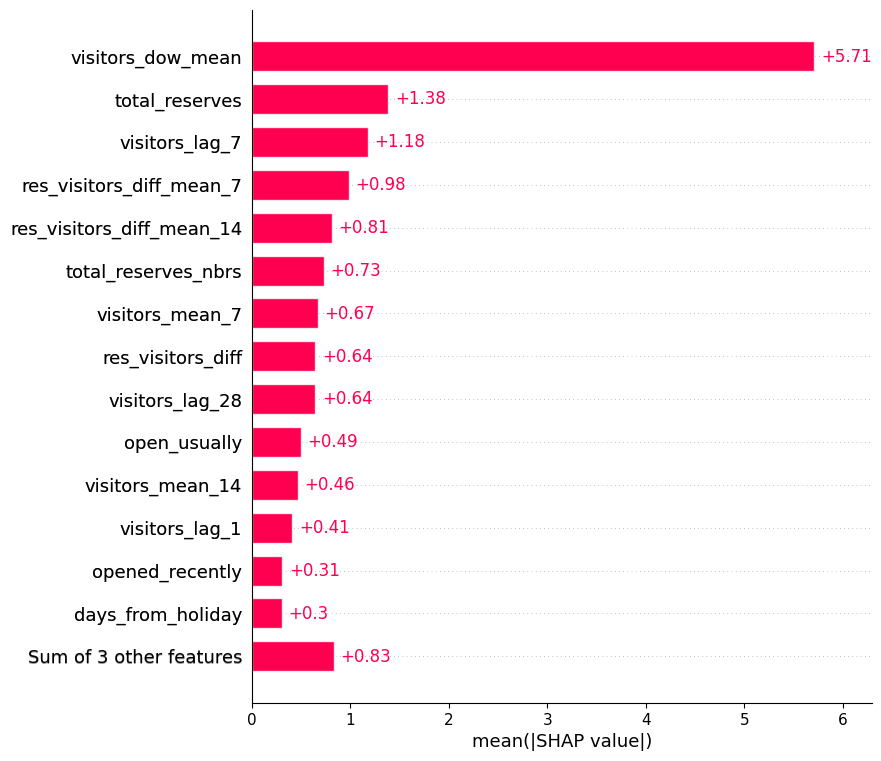

In [55]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

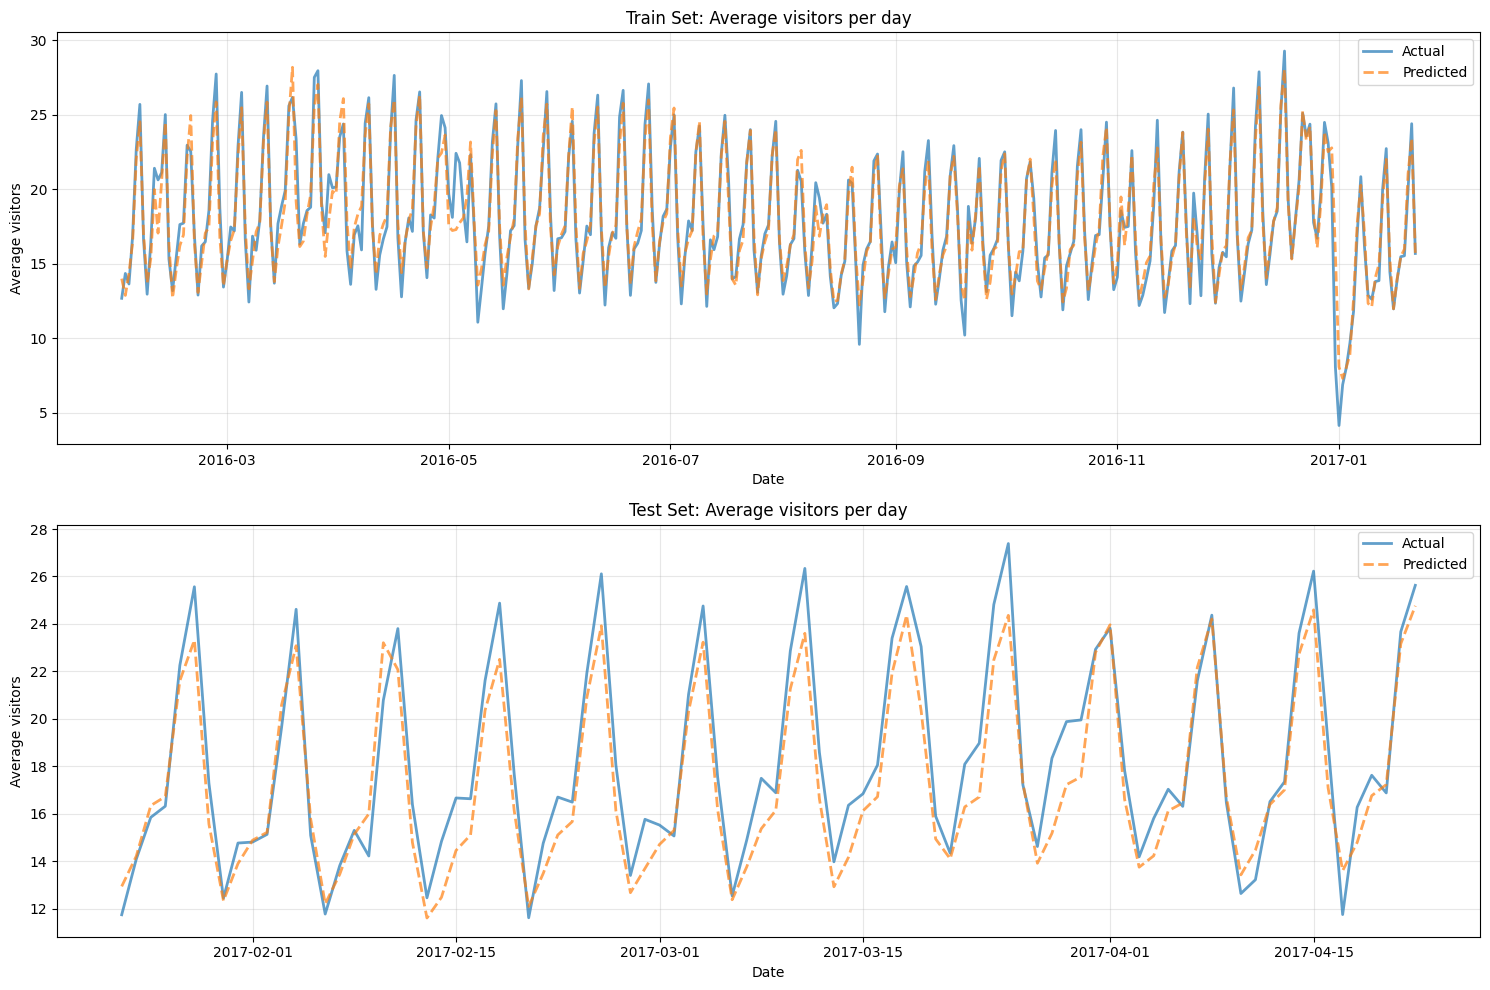

In [56]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

### Residuals

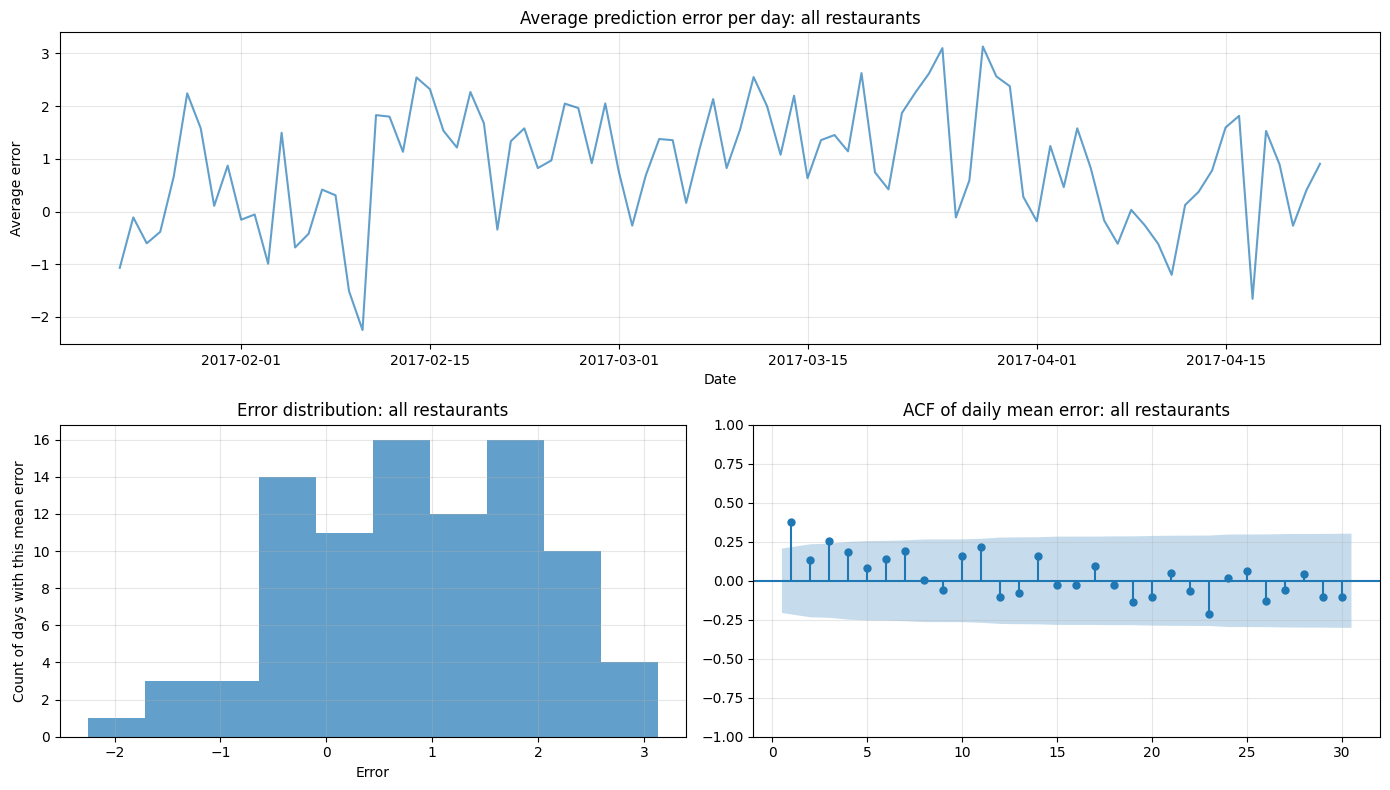

In [11]:
plot_daily_error_overall(X_test, y_test_pred, y_test)

The residuals have some seasonality, so it is likely that some dependence is not taken into account.

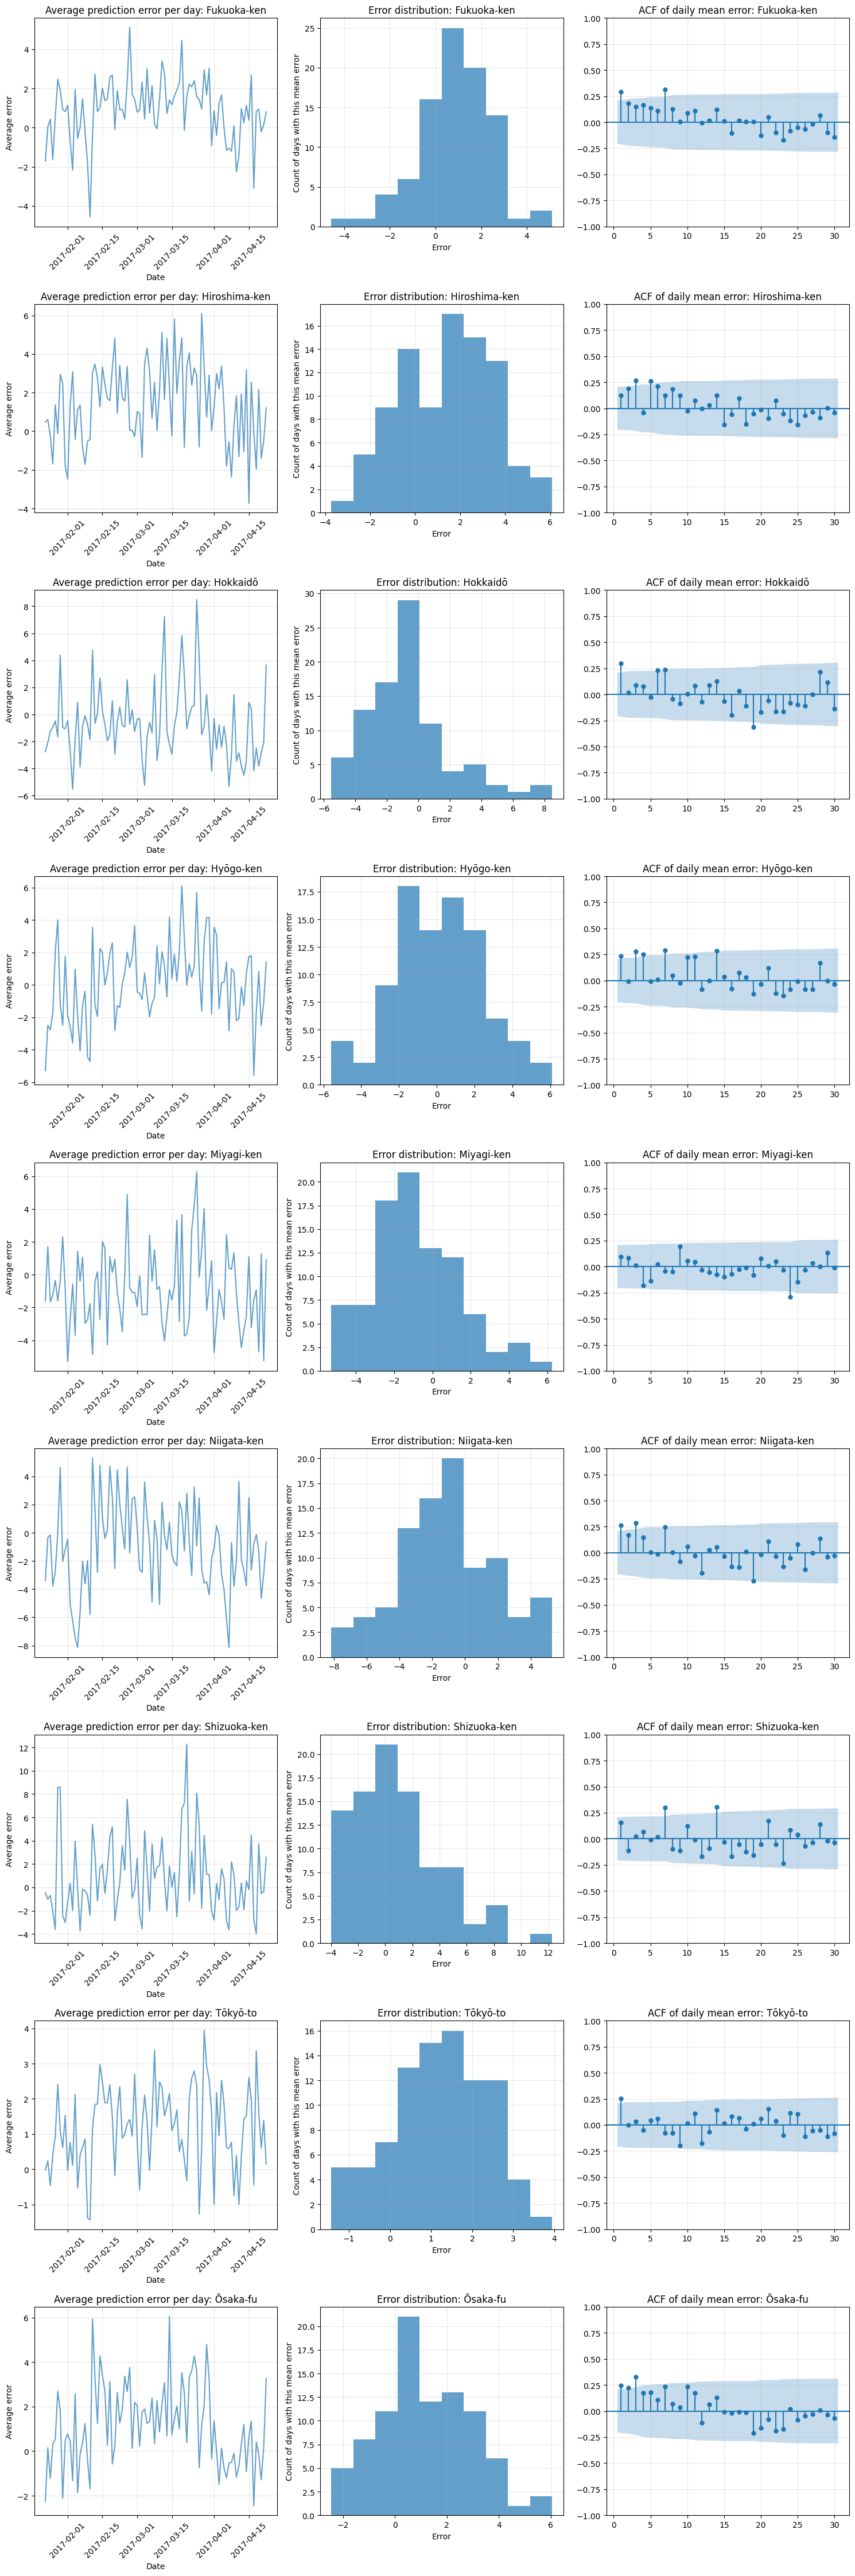

In [14]:
plot_daily_error_by_group(X_test, y_test_pred, y_test, CITY_COL)

The residuals averaged across cities don't differ significantly from each other on average. For most of them, the mean error increases between 2017-03 and 2017-04, but in some cities it's larger, and in others, smaller.

In [7]:
get_daily_error_stats_table(X_test, y_test_pred, y_test, CITY_COL)

,city,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Fukuoka-ken,0.877448,1.566317,0.008087,5.114107,-4.566334,0.295702,0.183692,0.150367,0.172450,0.140097,0.121005,0.346305,0.136859,0.004955,0.093093,0.117985,-0.007972,0.012012,0.139697
1,Hiroshima-ken,1.403258,2.051333,0.032822,6.092764,-3.725496,0.125915,0.189924,0.273875,-0.043605,0.272049,0.222728,0.128591,0.205901,0.138197,-0.032580,0.079353,-0.007276,0.025643,0.142710
2,Hokkaidō,-0.687450,2.630463,0.029116,8.488496,-5.527620,0.305427,0.017071,0.088765,0.083140,-0.029013,0.244888,0.255374,-0.046953,-0.094501,0.007204,0.094721,-0.085754,0.097179,0.143347
3,Hyōgo-ken,0.129915,2.386941,0.002233,6.114950,-5.577022,0.242933,-0.006571,0.292478,0.264757,-0.011255,0.009034,0.327867,0.054697,-0.030407,0.255515,0.266973,-0.103718,-0.010439,0.336553
4,Miyagi-ken,-0.857801,2.402026,0.074230,6.263326,-5.288589,0.092946,0.086639,0.015149,-0.190883,-0.142842,0.024317,-0.047531,-0.052779,0.211116,0.062369,0.052775,-0.036999,-0.066612,-0.088988
5,Niigata-ken,-1.055674,3.043205,0.007777,5.312288,-8.143234,0.265586,0.170153,0.289952,0.149270,0.007271,-0.011219,0.260711,0.004999,-0.088799,0.062170,-0.027899,-0.214187,0.029194,0.065466
6,Shizuoka-ken,0.911460,3.263347,0.018695,12.284290,-3.964947,0.155172,-0.116075,0.026504,0.071219,-0.006704,0.020554,0.339859,-0.112029,-0.131807,0.145972,-0.011940,-0.200231,-0.108090,0.357997
7,Tōkyō-to,1.186625,1.151570,0.015805,3.948896,-1.430255,0.256767,-0.001040,0.032651,-0.050043,0.047927,0.065458,-0.081873,-0.084974,-0.215154,0.018451,0.125497,-0.201534,-0.076837,0.167641
8,Ōsaka-fu,1.143107,1.827882,0.002057,6.060280,-2.456288,0.253503,0.230281,0.346020,0.181303,0.191218,0.113804,0.251757,0.076231,0.035927,0.256299,0.191265,-0.138750,0.063450,0.145624


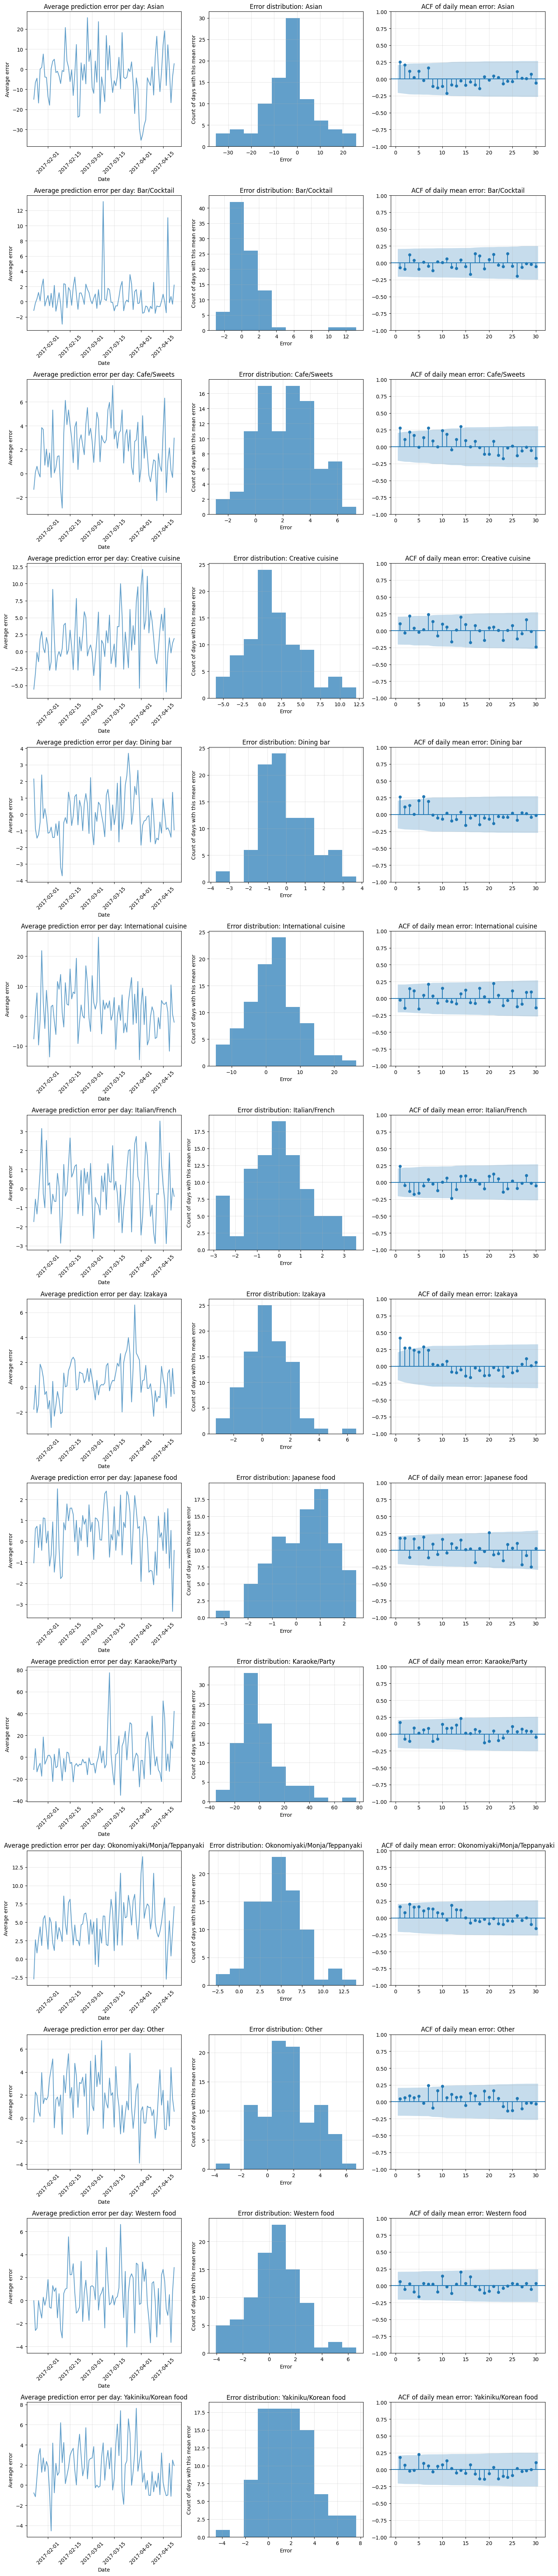

In [15]:
plot_daily_error_by_group(X_test, y_test_pred, y_test, AIR_GENRE_COL)

The largest residuals are observed for restaurants with the Asian and Karaoke/Party genres. However, firstly, the model doesn't consider the genre_te parameter. And if we recall the previous analysis, we see that there are fewer than five restaurants for each of these genres. Creating a different model for them is a questionable idea, but we can try removing the genre with some threshold and retraining the model.

In [8]:
get_daily_error_stats_table(X_test, y_test_pred, y_test, AIR_GENRE_COL)

,air_genre_name,mean_error,std_error,min_abs_error,max_pos_error,max_neg_error,acf_1,acf_2,acf_3,acf_4,acf_5,acf_6,acf_7,acf_8,acf_9,acf_10,acf_11,acf_12,acf_13,acf_14
0,Asian,-3.615470,11.988546,0.090842,25.671222,-35.396107,0.253062,0.211434,0.119122,0.022250,0.119261,-0.023182,0.174670,-0.113490,-0.138910,-0.116676,-0.228952,-0.094722,-0.110514,-0.025917
1,Bar/Cocktail,0.639847,2.164246,0.007329,13.160324,-2.964816,-0.068828,-0.090181,0.123127,0.040714,-0.108738,0.017587,-0.056013,-0.133618,0.023407,0.007677,0.071775,-0.078156,-0.101533,0.058250
2,Cafe/Sweets,2.221881,2.097002,0.043607,7.370491,-2.894839,0.283353,0.110639,0.226715,0.174843,-0.009749,0.146026,0.308833,0.094725,-0.000327,0.270174,0.211716,-0.058600,0.127502,0.362887
3,Creative cuisine,1.713830,3.739938,0.002958,12.101391,-5.947478,0.105589,-0.032678,0.226788,0.037768,-0.023676,0.017541,0.256416,0.148752,-0.082890,0.109875,0.060012,-0.182262,0.009023,0.229182
4,Dining bar,-0.073802,1.321105,0.005996,3.696461,-3.721515,0.268237,0.118070,0.144051,0.002683,0.216794,0.287516,0.214216,-0.005091,-0.050300,-0.070162,0.026299,-0.102023,-0.081647,0.040869
5,International cuisine,2.389956,7.684397,0.021152,26.388330,-14.588896,-0.020915,-0.144076,0.151220,0.121386,-0.165344,0.055167,0.236359,0.042053,-0.072264,0.172317,-0.047614,-0.057021,-0.089450,0.079793
6,Italian/French,0.011069,1.428814,0.007606,3.547169,-2.892042,0.239656,-0.046628,-0.135268,-0.183411,-0.163773,-0.053882,0.048647,-0.024780,-0.138219,0.004626,0.077323,-0.279095,-0.128559,0.114670
7,Izakaya,0.456719,1.581408,0.033497,6.604735,-3.238553,0.426063,0.276795,0.283853,0.249951,0.220969,0.307748,0.253464,0.034668,0.017542,0.027035,0.079569,-0.100214,-0.115363,-0.068312
8,Japanese food,0.340339,1.180284,0.020760,2.504726,-3.341963,0.182662,0.191012,-0.115884,0.183710,0.037814,0.215253,-0.126534,0.103360,-0.069291,0.184024,-0.048793,0.110792,0.041557,0.181268
9,Karaoke/Party,0.513831,17.903577,0.263079,77.413828,-34.970562,0.176356,-0.073857,-0.112034,0.093080,0.016420,0.066574,0.094122,-0.122863,-0.083505,0.173275,0.100194,0.112228,0.161770,0.280280


## Testing on future data

In [5]:
model_shap = joblib.load(MODEL_PATH)

In [20]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)
test_features = test_features.reset_index(drop=True)

In [21]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively: 100%|██████████| 39/39 [00:29<00:00,  1.31it/s]


In [24]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [24]:
with mlflow.start_run(run_name=MODEL_NAME):
    best_cv_result = cv_results.sort_values("rank_test_score").iloc[0].to_dict()
    mlflow.log_dict(
        best_cv_result,
        artifact_file="best_cv_result.json"
    )

    mlflow.log_param("cv_splits", CV_SPLITS)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("feature_selection_validation_size", FS_VALID_SIZE)
    mlflow.log_param("first_iteration_n_trials", FIRST_ITER_TRIALS)
    mlflow.log_param("second_iteration_n_trials", SECOND_ITER_TRIALS)
    mlflow.log_params(best_cv_result["params"])

    mlflow.log_metric("test_rmsle", test_rmsle)
    mlflow.log_metric("cv_mean_test_score", best_cv_result["mean_test_score"])
    mlflow.log_metric("cv_std_test_score", best_cv_result["std_test_score"])

    mlflow.sklearn.log_model(
        sk_model=model_shap,
        name="model"
    )

    mlflow.set_tags({
        "feature_ranking_method": "shap",
        "feature_selection_strategy": "top_k",
        "training_window_size": 39,
        "max_depth": "enabled"
    })

🏃 View run lgbm_optuna_recursive_new_genre_features at: http://localhost:5000/#/experiments/6/runs/82765a59ba7f493eb7c38b48f0042dbf
🧪 View experiment at: http://localhost:5000/#/experiments/6
